In [ ]:

# Parameterised Delta Forecasting Engine (Development Notebook)

# This notebook was used to design and experiment with the state-level
# time-series forecasting pipeline.

# Important design decisions:

# • Forecasting is performed at the **state × commodity** level.
# • Training start date is **dynamic and state-specific**.
# • National-level panel completeness flags (`is_valid_data`) are NOT used
#   for state-level forecasting.
# • Lag coherence is validated per state before training.
# • If exactly one required lag month is missing, forward-fill imputation is applied.
# • If more than one lag month is missing, forecasting is blocked.

# Production-ready logic is implemented in:
#     src/forecasting.py

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
# fixed values
RANDOM_STATE = 42
FORECAST_HORIZON = 3  # months
TRAIN_START_DATE = pd.Timestamp("2018-04-01")


In [42]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "data_for_model_with_validation_flags.csv"
)

In [43]:
# LOAD CLEANED FEATURE ENGINEERED DATA SET
df = pd.read_csv(DATA_PATH,parse_dates=["date"])

In [44]:
# --------------
# SANITY CHECKS
# --------------

In [45]:
df.head()

,state,date,month,year,quarter,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target
0,andaman and nicobar islands,2018-01-01,1,2018,1,0,False,rice,101.71,1220.90,0.00,101.67,100.21,0.10,67.326667,58.224578,407.87
1,andaman and nicobar islands,2018-02-01,2,2018,1,0,False,rice,116.73,13.70,0.00,101.71,101.67,100.21,101.196667,0.854712,414.05
2,andaman and nicobar islands,2018-03-01,3,2018,1,0,False,rice,116.19,7.17,0.00,116.73,101.71,101.67,106.703333,8.683371,429.04
3,andaman and nicobar islands,2018-04-01,4,2018,2,0,True,rice,407.87,12.97,180.92,116.19,116.73,101.71,111.543333,8.520196,436.08
4,andaman and nicobar islands,2018-05-01,5,2018,2,0,True,rice,414.05,40.12,169.25,407.87,116.19,116.73,213.596667,168.245859,423.13


In [46]:
df["date"].agg(["min", "max"])

min   2017-04-01
max   2021-07-01
Name: date, dtype: datetime64[ns]

In [47]:
df[["is_anomaly", "is_valid_data"]].value_counts()

is_anomaly  is_valid_data
0           True             1730
            False             151
1           True               99
            False              72
Name: count, dtype: int64

In [48]:
# CREATING DELTA TARGET
df["delta_target"] = df["target"] - df["total_allocated_qty"]
df[["total_allocated_qty", "target", "delta_target"]].head()

,total_allocated_qty,target,delta_target
0,101.71,407.87,306.16
1,116.73,414.05,297.32
2,116.19,429.04,312.85
3,407.87,436.08,28.21
4,414.05,423.13,9.08


In [49]:
# REMOVING CALENDAR FEATURES
df = df.drop(columns=[c for c in ["month", "quarter"] if c in df.columns])

In [ ]:
# # NOT NEEDED BELOW CODE AS WE ARE DOING STATE-LEVEL FORECASTING NOT NATIONAL-LEVEL
# df = (
#     df[
#         (df["is_anomaly"] == 0) &
#         (df["is_valid_data"] == True)
#     ]
#     .sort_values(["commodity", "state", "date"])
#     .reset_index(drop=True)
# )

In [51]:
df.head()

,state,date,year,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target,delta_target
0,andaman and nicobar islands,2018-04-01,2018,0,True,rice,407.87,12.97,180.92,116.19,116.73,101.71,111.543333,8.520196,436.08,28.21
1,andaman and nicobar islands,2018-05-01,2018,0,True,rice,414.05,40.12,169.25,407.87,116.19,116.73,213.596667,168.245859,423.13,9.08
2,andaman and nicobar islands,2018-06-01,2018,0,True,rice,429.04,31.28,190.62,414.05,407.87,116.19,312.703333,170.213589,416.77,-12.27
3,andaman and nicobar islands,2018-07-01,2018,0,True,rice,436.08,28.27,201.91,429.04,414.05,407.87,416.986667,10.886241,456.90,20.82
4,andaman and nicobar islands,2018-08-01,2018,0,True,rice,423.13,23.58,190.70,436.08,429.04,414.05,426.390000,11.251538,472.75,49.62


In [52]:
df["date"].agg(["min", "max"])

min   2018-04-01
max   2021-05-01
Name: date, dtype: datetime64[ns]

In [53]:
df["commodity"].value_counts()

commodity
rice     1029
wheat     701
Name: count, dtype: int64

In [54]:
# ----------------------------------------------------
# AUTOMATIC VALIDATION WINDOW AND LEAKAGE-SAFE SPLITS
# ----------------------------------------------------

In [55]:
def infer_validation_window(df, forecast_horizon):
    """
    Infers validation window based on last valid, non-anomalous date.
    Returns (val_start_date, val_end_date)
    """
    last_valid_date = df["date"].max()

    val_end_date = last_valid_date
    val_start_date = last_valid_date - pd.DateOffset(months=forecast_horizon - 1)

    return val_start_date, val_end_date

In [56]:
VAL_START_DATE, VAL_END_DATE = infer_validation_window(df, FORECAST_HORIZON)
VAL_START_DATE, VAL_END_DATE

(Timestamp('2021-03-01 00:00:00'), Timestamp('2021-05-01 00:00:00'))

In [57]:
def infer_train_end_date(val_start_date, forecast_horizon):
    """
    Computes the latest possible training end date
    to prevent leakage.
    """
    return val_start_date - pd.DateOffset(months=forecast_horizon)

In [58]:
TRAIN_END_DATE = infer_train_end_date(VAL_START_DATE, FORECAST_HORIZON)
TRAIN_END_DATE

Timestamp('2020-12-01 00:00:00')

In [59]:
def make_train_val_split(
    df,
    commodity,
    train_start_date,
    train_end_date,
    val_start_date,
    val_end_date
):
    df_c = (
        df[df["commodity"] == commodity]
        .sort_values(["state", "date"])
        .reset_index(drop=True)
    )

    train_df = (
        df_c[
            (df_c["date"] >= train_start_date) &
            (df_c["date"] < train_end_date)   # strict
        ]
        .reset_index(drop=True)
    )

    val_df = (
        df_c[
            (df_c["date"] >= val_start_date) &
            (df_c["date"] <= val_end_date)
        ]
        .reset_index(drop=True)
    )

    return train_df, val_df

In [60]:
def leakage_check(train_df, val_df, forecast_horizon):
    latest_train_target_date = (
        train_df["date"] + pd.DateOffset(months=forecast_horizon)
    ).max()

    earliest_val_feature_date = val_df["date"].min()

    print("Latest train target date :", latest_train_target_date)
    print("Earliest val feature date:", earliest_val_feature_date)

    assert latest_train_target_date < earliest_val_feature_date, \
        " !!!  DATA LEAKAGE DETECTED"

In [61]:
rice_train_df, rice_val_df = make_train_val_split(
    df=df,
    commodity="rice",
    train_start_date=TRAIN_START_DATE,
    train_end_date=TRAIN_END_DATE,
    val_start_date=VAL_START_DATE,
    val_end_date=VAL_END_DATE
)

leakage_check(rice_train_df, rice_val_df, FORECAST_HORIZON)

print("Rice train rows:", rice_train_df.shape[0])
print("Rice validation rows  :", rice_val_df.shape[0])

Latest train target date : 2021-02-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00
Rice train rows: 849
Rice validation rows  : 89


In [62]:
# --------------------------------- 
# FEATURE AND TARGET DEFINITIONS
# ---------------------------------

In [63]:
TARGET_COL = "delta_target"

In [64]:
NUMERIC_FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
]

CATEGORICAL_FEATURES = [
    "state"
]

In [65]:
def validate_columns(df, features, target):
    required = set(features + [target])
    missing = required - set(df.columns)
    assert len(missing) == 0, f"Missing columns: {missing}"

In [66]:
# ------------------------------------------------
# FRESH PIPELINE FOR EACH TIME + PREPROCESSING
# ------------------------------------------------

In [67]:
def build_pipeline(numeric_features, categorical_features, random_state):
    numeric_transformer = Pipeline(
        steps=[("passthrough", "passthrough")]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [68]:
# -------------------------------------
# TRAIN + PREDICT (FOR ONE COMMODITY)
# -------------------------------------

In [69]:
def train_and_evaluate(
    train_df,
    val_df,
    numeric_features,
    categorical_features,
    target_col,
    random_state
):
    # Column safety
    validate_columns(train_df, numeric_features + categorical_features, target_col)
    validate_columns(val_df, numeric_features + categorical_features, target_col)

    X_train = train_df[numeric_features + categorical_features]
    y_train = train_df[target_col]

    X_val = val_df[numeric_features + categorical_features]
    y_val = val_df[target_col]

    pipeline = build_pipeline(
        numeric_features,
        categorical_features,
        random_state
    )

    pipeline.fit(X_train, y_train)

    # Delta prediction
    delta_pred = pipeline.predict(X_val)

    # Reconstruct level predictions
    level_pred = val_df["total_allocated_qty"].values + delta_pred
    level_true = val_df["target"].values

    return {
        "pipeline": pipeline,
        "level_true": level_true,
        "level_pred": level_pred,
        "train_df": train_df,
        "val_df": val_df
    }

In [70]:
# ----------------------
# METRICS COMPUTATION
# ----------------------

In [71]:
def compute_metrics(level_true, level_pred, train_df):
    mae = mean_absolute_error(level_true, level_pred)
    rmse = np.sqrt(mean_squared_error(level_true, level_pred))
    r2 = r2_score(level_true, level_pred)

    train_mean = train_df["target"].mean()
    train_std = train_df["target"].std()

    nmae = mae / train_mean
    nrmse = rmse / train_std

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "nMAE": nmae,
        "nRMSE": nrmse
    }

In [72]:
# CHECKING WITH RICE
rice_train_df, rice_val_df = make_train_val_split(
    df=df,
    commodity="rice",
    train_start_date=TRAIN_START_DATE,
    train_end_date=TRAIN_END_DATE,
    val_start_date=VAL_START_DATE,
    val_end_date=VAL_END_DATE
)

leakage_check(rice_train_df, rice_val_df, FORECAST_HORIZON)

rice_results = train_and_evaluate(
    rice_train_df,
    rice_val_df,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET_COL,
    RANDOM_STATE
)

rice_metrics = compute_metrics(
    rice_results["level_true"],
    rice_results["level_pred"],
    rice_train_df
)

rice_metrics

Latest train target date : 2021-02-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00


{'MAE': 21325.210673541493,
 'RMSE': np.float64(37573.18899979146),
 'R2': 0.8368710346024911,
 'nMAE': np.float64(0.193100751518224),
 'nRMSE': np.float64(0.25134342452697084)}

In [73]:
# -----------------------------------------------
# VISUALISATION - PLOTTING ACTUALS VS PREDICTED
# -----------------------------------------------

In [74]:
def plot_actual_vs_predicted(results, commodity_name):
    train_df = results["train_df"]
    val_df = results["val_df"]
    level_pred = results["level_pred"]

    # Combine actuals (train + val)
    actuals_df = pd.concat(
        [
            train_df[["date", "target"]],
            val_df[["date", "target"]],
        ],
        ignore_index=True
    )

    actuals_monthly = (
        actuals_df
        .groupby("date")["target"]
        .sum()
        .reset_index()
    )

    # Validation predictions only
    val_preds_df = val_df[["date"]].copy()
    val_preds_df["predicted"] = level_pred

    val_preds_monthly = (
        val_preds_df
        .groupby("date")["predicted"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        actuals_monthly["date"],
        actuals_monthly["target"],
        label="Actual",
        color="blue"
    )

    plt.plot(
        val_preds_monthly["date"],
        val_preds_monthly["predicted"],
        label="Predicted",
        color="orange",
        marker="o"
    )

    plt.axvline(
        x=val_preds_monthly["date"].min(),
        linestyle=":",
        color="grey",
        label="Forecast Start"
    )

    plt.title(f"{commodity_name.capitalize()} — Actual vs Predicted (Delta RF)")
    plt.xlabel("Date")
    plt.ylabel("Total Allocated Quantity")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [75]:
def run_forecast_for_commodity(df, commodity):
    # Infer validation window
    val_start, val_end = infer_validation_window(df, FORECAST_HORIZON)
    train_end = infer_train_end_date(val_start, FORECAST_HORIZON)

    # Train / Val split
    train_df, val_df = make_train_val_split(
        df=df,
        commodity=commodity,
        train_start_date=TRAIN_START_DATE,
        train_end_date=train_end,
        val_start_date=val_start,
        val_end_date=val_end
    )

    leakage_check(train_df, val_df, FORECAST_HORIZON)

    # Train + evaluate
    results = train_and_evaluate(
        train_df,
        val_df,
        NUMERIC_FEATURES,
        CATEGORICAL_FEATURES,
        TARGET_COL,
        RANDOM_STATE
    )

    metrics = compute_metrics(
        results["level_true"],
        results["level_pred"],
        train_df
    )

    print(f"\n===== {commodity.upper()} RESULTS =====")
    print(f"R²    : {metrics['R2']:.3f}")
    #print(f"nMAE  : {metrics['nMAE']*100:.2f}%")
    print(f"nRMSE : {metrics['nRMSE']:.3f}")

    plot_actual_vs_predicted(results, commodity)

    return metrics, results

Latest train target date : 2021-02-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00

===== RICE RESULTS =====
R²    : 0.837
nRMSE : 0.251


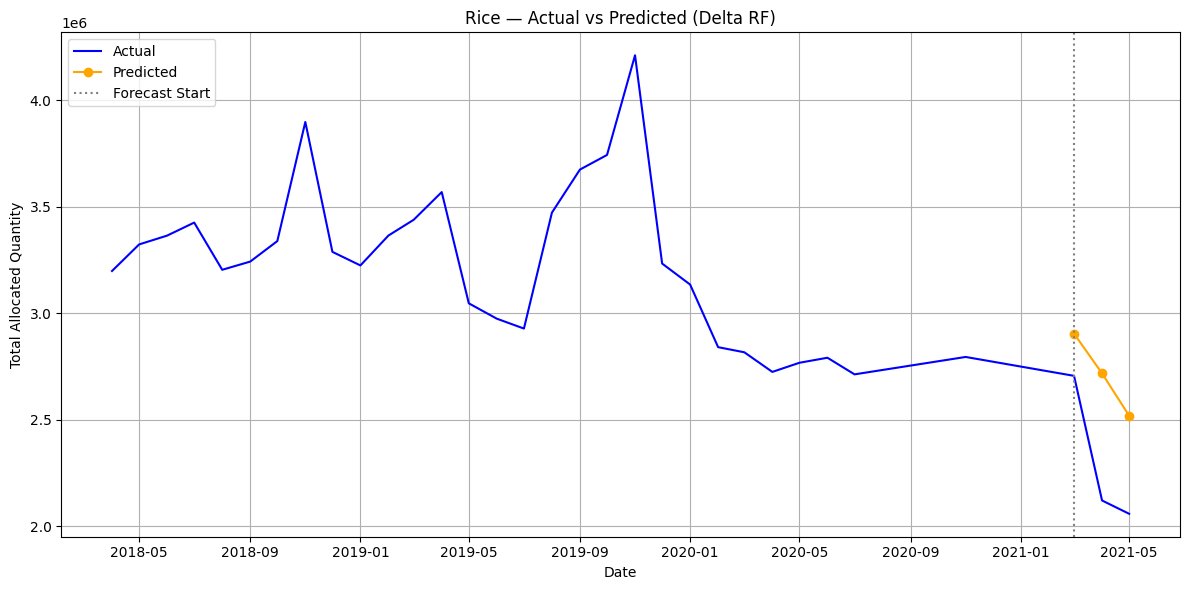

Latest train target date : 2021-02-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00

===== WHEAT RESULTS =====
R²    : 0.744
nRMSE : 0.341


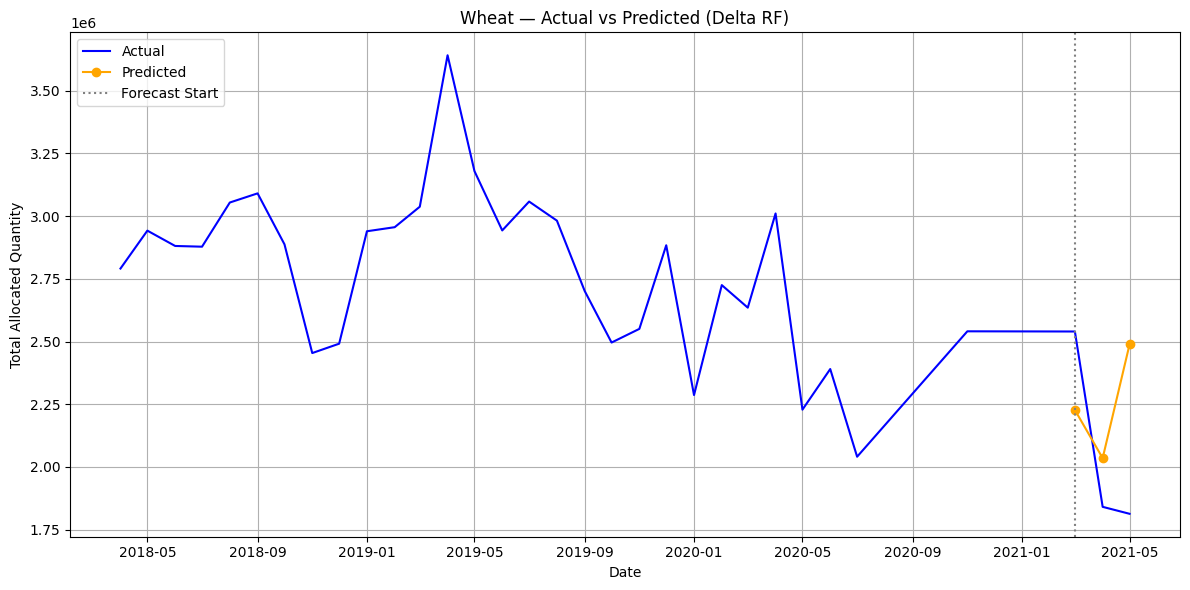

In [76]:
rice_metrics, rice_results = run_forecast_for_commodity(df, "rice")
wheat_metrics, wheat_results = run_forecast_for_commodity(df, "wheat")

In [77]:
# ------------------------------------------
# FRONT END - FOR USER SPECIFIED MONTH
# ------------------------------------------


In [78]:
def run_forecast_for_cutoff(df, year, month):
    cutoff_date = pd.Timestamp(year=year, month=month, day=1)

    # Restrict dataset to cutoff
    df_cut = df[df["date"] <= cutoff_date].copy()

    print(f"\nRunning forecast with cutoff: {cutoff_date.date()}")

    rice_metrics, _ = run_forecast_for_commodity(df_cut, "rice")
    wheat_metrics, _ = run_forecast_for_commodity(df_cut, "wheat")

    return {
        "rice": rice_metrics,
        "wheat": wheat_metrics
    }